# 02 — Model Training: All Labels × All Models × All Metals

Trains **5 models** on **6 label variants** for **4 metals** = 120 experiments.

| Models | Label Variants | Metals |
|--------|----------------|--------|
| LASSO (L1 logistic) | GSADF | Cobalt |
| Random Forest | LPPLS 0.30 / 0.20 / 0.10 / 0.05 | Copper |
| XGBoost | LPPLS Period-based | Lithium |
| LightGBM | | Nickel |
| CatBoost | | |

### Approach
- **Features**: lagged log-returns, rolling volatility, lagged price levels, peer bubble dummies — ALL lagged by 1 day (no look-ahead)
- **CV**: 5-fold expanding-window `TimeSeriesSplit` — scaler fitted on train fold only
- **No SMOTE** — oversampling causes single-cluster detection
- **Metrics**: AUC, F1 (threshold-optimized), Sensitivity, Precision, Episodes detected

### Output
- `outputs/all_results.csv` — full results table
- `outputs/best_per_metal.csv` — best model per metal per label variant


In [1]:
import pandas as pd, numpy as np, os, warnings, time
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (roc_auc_score, confusion_matrix,
                              precision_recall_curve)
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import optuna
import shap
import matplotlib.pyplot as plt
optuna.logging.set_verbosity(optuna.logging.WARNING)

os.makedirs('../outputs', exist_ok=True)

# ── Load all_labels.csv ───────────────────────────────────────────────────
DATA_PATH = '../outputs/all_labels.csv'
assert os.path.exists(DATA_PATH), f'{DATA_PATH} not found — run 01_data_preparation first'
df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])

METALS = {'Cobalt': 'CODALY', 'Copper': 'CUDALY', 'Lithium': 'LIDALY', 'Nickel': 'NIDALY'}
LABEL_VARIANTS = [
    'gsadf_ols', 'gsadf_ols_period', 'gsadf_v1', 'gsadf_v1_period',
    'lppls_0.20', 'lppls_0.20_period',
    'lppls_0.10', 'lppls_0.10_period',
    'lppls_0.01', 'lppls_0.01_period',
]
NEEDS_SCALE = {'LASSO'}   # only linear model needs StandardScaler

print(f'Data: {len(df)} rows, {len(df.columns)} columns')
print(f'Metals: {list(METALS.keys())}')
print(f'Label variants ({len(LABEL_VARIANTS)}): {LABEL_VARIANTS}')
print(f'Total experiments: {len(LABEL_VARIANTS)} × 5 models × 4 metals = {len(LABEL_VARIANTS)*5*4}')


Data: 2152 rows, 57 columns
Metals: ['Cobalt', 'Copper', 'Lithium', 'Nickel']
Label variants (10): ['gsadf_ols', 'gsadf_ols_period', 'gsadf_v1', 'gsadf_v1_period', 'lppls_0.20', 'lppls_0.20_period', 'lppls_0.10', 'lppls_0.10_period', 'lppls_0.01', 'lppls_0.01_period']
Total experiments: 10 × 5 models × 4 metals = 200


In [2]:
# ═══════════════════════════════════════════════════════════════════════════
#  Helper Functions
# ═══════════════════════════════════════════════════════════════════════════

def prepare_features(target_metal, label_variant, df_master):
    """Create lagged feature matrix. No look-ahead."""
    target_col = f'{target_metal}_{label_variant}'
    price_cols = ['CODALY', 'CUDALY', 'LIDALY', 'NIDALY']
    macro_cols = [c for c in df_master.columns
                  if c not in ['Date'] + price_cols
                  and not any(c.startswith(m + '_') for m in
                              ['Cobalt', 'Copper', 'Lithium', 'Nickel'])]
    num_cols = price_cols + macro_cols

    peer_cols = [f'{m}_{label_variant}' for m in
                 ['Cobalt', 'Copper', 'Lithium', 'Nickel'] if m != target_metal]
    peer_cols = [c for c in peer_cols if c in df_master.columns]

    out = pd.DataFrame({'Date': df_master['Date']})
    for col in num_cols:
        safe = df_master[col].clip(lower=0.001)
        lr = np.log(safe).diff()
        out[col + '_Ret_L1']   = lr.shift(1)
        out[col + '_Vol10_L1'] = lr.rolling(10).std().shift(1)
    for col in num_cols:
        out[col + '_Level_L1'] = df_master[col].shift(1)
    for col in peer_cols:
        out[col + '_L1'] = df_master[col].shift(1).fillna(0)

    out['Target'] = df_master[target_col].astype(int)
    return out.dropna().reset_index(drop=True)


def find_f1_threshold(y_true, y_prob):
    """Find threshold that maximises F1."""
    pre, rec, thr = precision_recall_curve(y_true, y_prob)
    with np.errstate(invalid='ignore'):
        f1s = np.where((pre[:-1] + rec[:-1]) > 0,
                       2 * pre[:-1] * rec[:-1] / (pre[:-1] + rec[:-1]), 0.0)
    return float(thr[int(np.argmax(f1s))]), float(f1s.max())


def label_episodes(y):
    """Return episode id (1-based) per positive day."""
    eps = np.zeros(len(y), dtype=int)
    eid = 0; in_b = False
    for i in range(len(y)):
        if y[i] == 1 and not in_b:
            eid += 1; in_b = True
        elif y[i] == 0:
            in_b = False
        if y[i] == 1:
            eps[i] = eid
    return eps


# ── Optuna helpers ─────────────────────────────────────────────────────────

def build_model(mname, params):
    """Instantiate a model from its name and a params dict."""
    if mname == 'LASSO':
        return LogisticRegression(penalty='l1', solver='saga',
                                   max_iter=10000, random_state=42, **params)
    if mname == 'LightGBM':
        return lgb.LGBMClassifier(**params, verbose=-1, random_state=42)
    if mname == 'XGBoost':
        return xgb.XGBClassifier(**params, eval_metric='auc',
                                  verbosity=0, random_state=42)
    if mname == 'RF':
        return RandomForestClassifier(**params, random_state=42)
    if mname == 'CatBoost':
        return CatBoostClassifier(**params, verbose=0, random_state=42)
    raise ValueError(f'Unknown model: {mname}')


def suggest_params(trial, mname):
    """Return Optuna-suggested hyperparameter dict for a given model."""
    if mname == 'LASSO':
        return {'C': trial.suggest_float('C', 1e-4, 10.0, log=True)}
    if mname == 'LightGBM':
        return {
            'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
            'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'num_leaves':        trial.suggest_int('num_leaves', 16, 128),
            'max_depth':         trial.suggest_int('max_depth', 3, 8),
            'reg_alpha':         trial.suggest_float('reg_alpha', 1e-3, 5.0, log=True),
            'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 5.0, log=True),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 30),
            'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        }
    if mname == 'XGBoost':
        return {
            'max_depth':        trial.suggest_int('max_depth', 2, 8),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
            'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha':        trial.suggest_float('reg_alpha', 1e-3, 5.0, log=True),
            'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 5.0, log=True),
        }
    if mname == 'RF':
        return {
            'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
            'max_depth':        trial.suggest_int('max_depth', 3, 15),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
            'max_features':     trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        }
    if mname == 'CatBoost':
        return {
            'depth':         trial.suggest_int('depth', 3, 8),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'iterations':    trial.suggest_int('iterations', 100, 500),
            'l2_leaf_reg':   trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
            'subsample':     trial.suggest_float('subsample', 0.6, 1.0),
        }
    raise ValueError(f'Unknown model: {mname}')


def make_optuna_objective(X, y, mname):
    """Return an Optuna objective: maximise 5-fold time-series CV AUC."""
    def objective(trial):
        params = suggest_params(trial, mname)
        scores = []
        for tr_idx, te_idx in TimeSeriesSplit(n_splits=5).split(X):
            Xtr, Xte = X[tr_idx], X[te_idx]
            ytr, yte = y[tr_idx], y[te_idx]
            if ytr.sum() < 5 or yte.sum() == 0 or len(np.unique(yte)) < 2:
                continue
            if mname in NEEDS_SCALE:
                sc = StandardScaler()
                Xtr = sc.fit_transform(Xtr)
                Xte = sc.transform(Xte)
            m = build_model(mname, params)
            m.fit(Xtr, ytr)
            scores.append(roc_auc_score(yte, m.predict_proba(Xte)[:, 1]))
        return np.mean(scores) if scores else 0.0
    return objective


print('Helpers ready.')


Helpers ready.


## 1. Run All Experiments

In [3]:
MODELS = {
    'LASSO': lambda: LogisticRegression(
        penalty='l1', solver='saga', C=0.1, max_iter=10000, random_state=42),
    'RF': lambda: RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=3,
        max_features='sqrt', random_state=42),
    'XGBoost': lambda: xgb.XGBClassifier(
        max_depth=3, learning_rate=0.05, n_estimators=300,
        min_child_weight=2, reg_alpha=0.5, reg_lambda=2.0,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='auc', verbosity=0, random_state=42),
    'LightGBM': lambda: lgb.LGBMClassifier(
        max_depth=3, learning_rate=0.05, n_estimators=300,
        min_child_samples=5, reg_alpha=0.5, reg_lambda=2.0,
        subsample=0.8, colsample_bytree=0.8,
        verbose=-1, random_state=42),
    'CatBoost': lambda: CatBoostClassifier(
        depth=3, learning_rate=0.05, iterations=300,
        l2_leaf_reg=3.0, subsample=0.8,
        verbose=0, random_state=42),
}

# Models that need StandardScaler (linear only)
NEEDS_SCALE = {'LASSO'}

N_SPLITS = 5
results = []
t0 = time.time()
total_exp = len(METALS) * len(LABEL_VARIANTS) * len(MODELS)
exp_i = 0

for metal in METALS:
    for variant in LABEL_VARIANTS:
        label_col = f'{metal}_{variant}'
        if label_col not in df.columns:
            continue

        # Skip if too few positives
        n_pos_total = int(df[label_col].sum())
        if n_pos_total < 10:
            for mname in MODELS:
                exp_i += 1
                results.append(dict(
                    Metal=metal, Variant=variant, Model=mname,
                    BubDays=n_pos_total, AUC=np.nan, F1=np.nan,
                    Sens=np.nan, Prec=np.nan, Spec=np.nan,
                    Detected='0/0', EpDet='0/0', Note='too_few_pos'))
            continue

        # Prepare features (all lagged — no look-ahead)
        df_ml = prepare_features(metal, variant, df)
        feats = [c for c in df_ml.columns if c not in ['Date', 'Target']]
        X = df_ml[feats].values
        y = df_ml['Target'].values
        dates_arr = df_ml['Date']

        for mname, model_fn in MODELS.items():
            exp_i += 1
            tscv = TimeSeriesSplit(n_splits=N_SPLITS)
            all_p, all_t = [], []

            for train_idx, test_idx in tscv.split(X):
                Xtr, Xte = X[train_idx], X[test_idx]
                ytr, yte = y[train_idx], y[test_idx]

                if ytr.sum() < 5 or yte.sum() == 0:
                    continue

                # Scale fitted on train only — no spillover
                if mname in NEEDS_SCALE:
                    sc = StandardScaler()
                    Xtr = sc.fit_transform(Xtr)
                    Xte = sc.transform(Xte)

                m = model_fn()
                m.fit(Xtr, ytr)
                p = m.predict_proba(Xte)[:, 1]
                all_p.append(p)
                all_t.append(yte)

            if not all_p:
                results.append(dict(
                    Metal=metal, Variant=variant, Model=mname,
                    BubDays=n_pos_total, AUC=np.nan, F1=np.nan,
                    Sens=np.nan, Prec=np.nan, Spec=np.nan,
                    Detected='0/0', EpDet='0/0', Note='no_valid_fold'))
                continue

            yt = np.concatenate(all_t)
            yp = np.concatenate(all_p)

            auc = roc_auc_score(yt, yp)
            opt_t, opt_f1 = find_f1_threshold(yt, yp)
            ypred = (yp >= opt_t).astype(int)
            tn, fp, fn, tp = confusion_matrix(yt, ypred, labels=[0, 1]).ravel()
            sens = tp / (tp + fn) if (tp + fn) > 0 else 0
            spec = tn / (tn + fp) if (tn + fp) > 0 else 0
            prec = tp / (tp + fp) if (tp + fp) > 0 else 0

            # Episode detection
            eps = label_episodes(yt)
            ep_total = set(eps[eps > 0])
            ep_det = {eid for eid in ep_total if ypred[eps == eid].sum() > 0}

            results.append(dict(
                Metal=metal, Variant=variant, Model=mname,
                BubDays=n_pos_total,
                AUC=round(auc, 3), F1=round(opt_f1, 3),
                Sens=round(sens, 3), Prec=round(prec, 3), Spec=round(spec, 3),
                Detected=f'{tp}/{tp+fn}',
                EpDet=f'{len(ep_det)}/{len(ep_total)}',
                Note=''))

            if exp_i % 15 == 0 or exp_i == total_exp:
                elapsed = time.time() - t0
                print(f'  [{exp_i:3d}/{total_exp}]  {elapsed:.0f}s  '
                      f'{metal:8s} {variant:14s} {mname:8s}  '
                      f'AUC={auc:.3f} F1={opt_f1:.3f}')

df_results = pd.DataFrame(results)
df_results.to_csv('../outputs/all_results.csv', index=False)
print(f'\nDone! {len(df_results)} experiments in {time.time()-t0:.0f}s')
print(f'Saved → outputs/all_results.csv')


  [ 15/200]  79s  Cobalt   gsadf_v1       CatBoost  AUC=0.762 F1=0.275
  [ 30/200]  105s  Cobalt   lppls_0.20_period CatBoost  AUC=0.474 F1=0.022
  [ 45/200]  155s  Cobalt   lppls_0.01     CatBoost  AUC=0.697 F1=0.198
  [ 60/200]  182s  Copper   gsadf_ols_period CatBoost  AUC=0.993 F1=0.737
  [ 75/200]  210s  Copper   lppls_0.20     CatBoost  AUC=0.760 F1=0.145
  [ 90/200]  264s  Copper   lppls_0.10_period CatBoost  AUC=0.645 F1=0.284
  [105/200]  314s  Lithium  gsadf_ols      CatBoost  AUC=0.431 F1=0.523
  [120/200]  363s  Lithium  gsadf_v1_period CatBoost  AUC=0.693 F1=0.469
  [135/200]  381s  Lithium  lppls_0.10     CatBoost  AUC=0.562 F1=0.200
  [150/200]  408s  Lithium  lppls_0.01_period CatBoost  AUC=0.499 F1=0.201
  [165/200]  412s  Nickel   gsadf_v1       CatBoost  AUC=0.703 F1=0.308
  [180/200]  429s  Nickel   lppls_0.20_period CatBoost  AUC=0.239 F1=0.068
  [195/200]  446s  Nickel   lppls_0.01     CatBoost  AUC=0.467 F1=0.248
  [200/200]  454s  Nickel   lppls_0.01_period CatB

## 2. Results Overview

In [4]:
import matplotlib.pyplot as plt

df_r = df_results[df_results.Note != 'too_few_pos'].copy()
df_r = df_r[df_r.AUC.notna()].copy()

# ── Best model per metal per variant ──────────────────────────────────────
best = df_r.loc[df_r.groupby(['Metal', 'Variant'])['F1'].idxmax()].copy()
best = best.sort_values(['Metal', 'F1'], ascending=[True, False])
best.to_csv('../outputs/best_per_metal.csv', index=False)

print('Best model per metal per label variant (by F1):')
print('=' * 100)
print(f'{"Metal":>8s}  {"Variant":>14s}  {"Model":>8s}  '
      f'{"BubDays":>7s}  {"AUC":>5s}  {"F1":>5s}  {"Sens":>5s}  '
      f'{"Prec":>5s}  {"Detected":>8s}  {"EpDet":>7s}')
print('-' * 100)
for _, r in best.iterrows():
    print(f'{r.Metal:>8s}  {r.Variant:>14s}  {r.Model:>8s}  '
          f'{r.BubDays:>7d}  {r.AUC:>5.3f}  {r.F1:>5.3f}  {r.Sens:>5.3f}  '
          f'{r.Prec:>5.3f}  {r.Detected:>8s}  {r.EpDet:>7s}')

print(f'\nSaved → outputs/best_per_metal.csv')

Best model per metal per label variant (by F1):
   Metal         Variant     Model  BubDays    AUC     F1   Sens   Prec  Detected    EpDet
----------------------------------------------------------------------------------------------------
  Cobalt      lppls_0.01     LASSO       64  0.909  0.515  0.593  0.455     35/59      5/7
  Cobalt      lppls_0.20     LASSO       20  0.981  0.500  1.000  0.333       5/5      1/1
  Cobalt  lppls_0.20_period     LASSO       17  0.978  0.429  1.000  0.273       3/3      1/1
  Cobalt      lppls_0.10     LASSO       53  0.895  0.415  0.562  0.329     27/48      6/6
  Cobalt       gsadf_ols     LASSO      135  0.572  0.366  0.697  0.249    83/119      3/6
  Cobalt  gsadf_ols_period     LASSO      135  0.572  0.366  0.697  0.249    83/119      3/6
  Cobalt  gsadf_v1_period  CatBoost       77  0.726  0.345  0.358  0.333     19/53      4/5
  Cobalt  lppls_0.01_period     LASSO       92  0.753  0.322  0.759  0.205     63/83      3/5
  Cobalt  lppls_0.10_pe

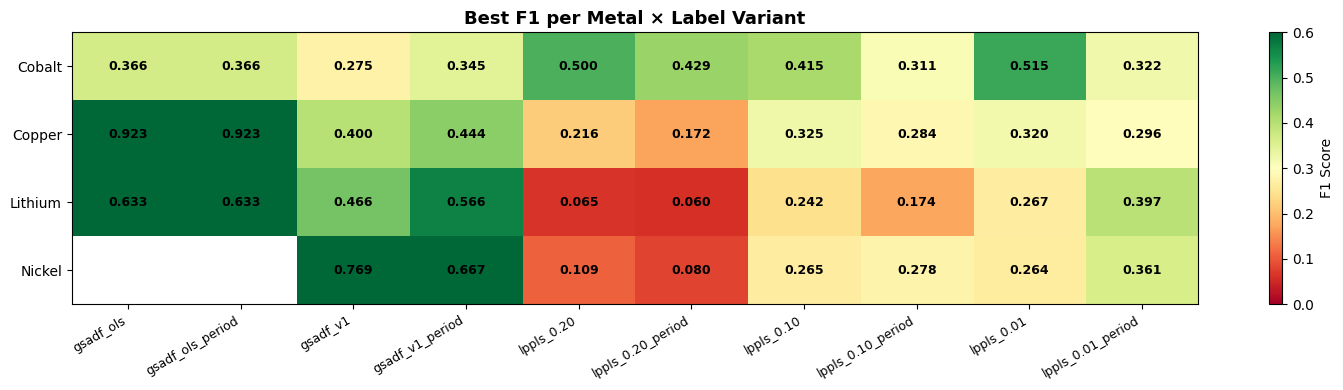

In [5]:
# ── Heatmap: F1 by (Metal×Variant) for best model ────────────────────────
pivot = best.pivot_table(index='Metal', columns='Variant', values='F1')
pivot = pivot.reindex(columns=LABEL_VARIANTS)

fig, ax = plt.subplots(figsize=(15, 4))
im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=0.6)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=10)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.iloc[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=9, fontweight='bold')

plt.colorbar(im, ax=ax, label='F1 Score')
ax.set_title('Best F1 per Metal × Label Variant', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/02_f1_heatmap.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


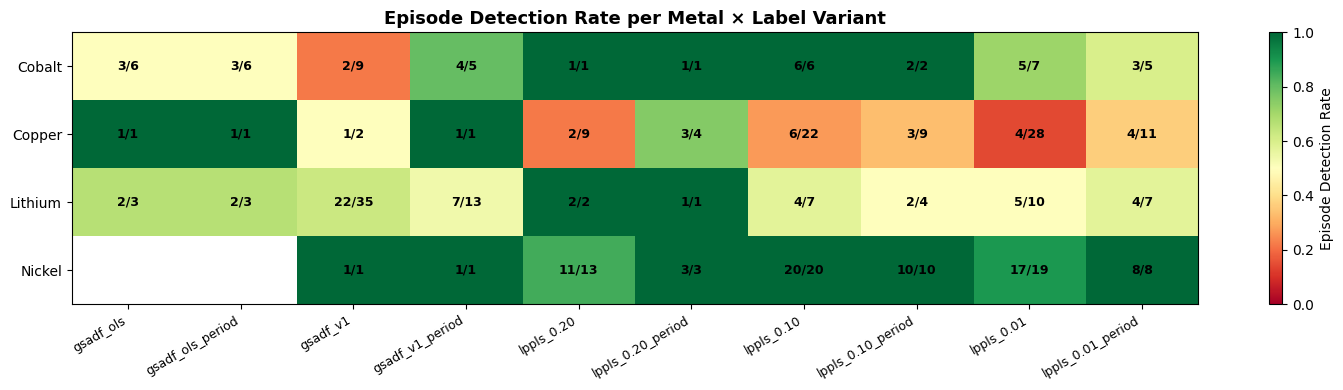


All results saved. Proceed to 03_master_summary.ipynb for analysis.


In [6]:
# ── Heatmap: Episode Detection Rate ──────────────────────────────────────
def ep_rate(s):
    """Parse '5/7' -> 5/7 = 0.714"""
    parts = s.split('/')
    if len(parts) == 2 and int(parts[1]) > 0:
        return int(parts[0]) / int(parts[1])
    return np.nan

best['EpRate'] = best['EpDet'].apply(ep_rate)

pivot_ep = best.pivot_table(index='Metal', columns='Variant', values='EpRate')
pivot_ep = pivot_ep.reindex(columns=LABEL_VARIANTS)

fig, ax = plt.subplots(figsize=(15, 4))
im = ax.imshow(pivot_ep.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1.0)
ax.set_xticks(range(len(pivot_ep.columns)))
ax.set_xticklabels(pivot_ep.columns, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot_ep.index)))
ax.set_yticklabels(pivot_ep.index, fontsize=10)

for i in range(len(pivot_ep.index)):
    for j in range(len(pivot_ep.columns)):
        val = pivot_ep.iloc[i, j]
        if not np.isnan(val):
            ep_str = best[(best.Metal == pivot_ep.index[i]) &
                          (best.Variant == pivot_ep.columns[j])]['EpDet'].values
            txt = ep_str[0] if len(ep_str) > 0 else f'{val:.0%}'
            ax.text(j, i, txt, ha='center', va='center', fontsize=9, fontweight='bold')

plt.colorbar(im, ax=ax, label='Episode Detection Rate')
ax.set_title('Episode Detection Rate per Metal × Label Variant', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/02_episode_heatmap.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print('\nAll results saved. Proceed to 03_master_summary.ipynb for analysis.')


## 3. Optuna Hyperparameter Fine-tuning

For each metal's **winning model + label variant** (determined above), we run
[Optuna](https://optuna.org) TPE Bayesian search (35 trials) to find better
hyperparameters than the default grid — without re-running all 120 experiments.

The scaler is **always fitted on the train fold only** inside each trial, so
there is no data spillover across folds.


Fine-tuning 4 winners with Optuna (35 trials each):

     Metal         Variant       Model  AUC_base  AUC_tuned       Δ
--------------------------------------------------------------------
    Cobalt      lppls_0.01       LASSO     0.909      0.931  +0.022
    Copper       gsadf_ols       LASSO     0.998      0.998  +0.000
   Lithium       gsadf_ols     XGBoost     0.501      0.785  +0.284
    Nickel        gsadf_v1       LASSO     0.928      0.942  +0.014


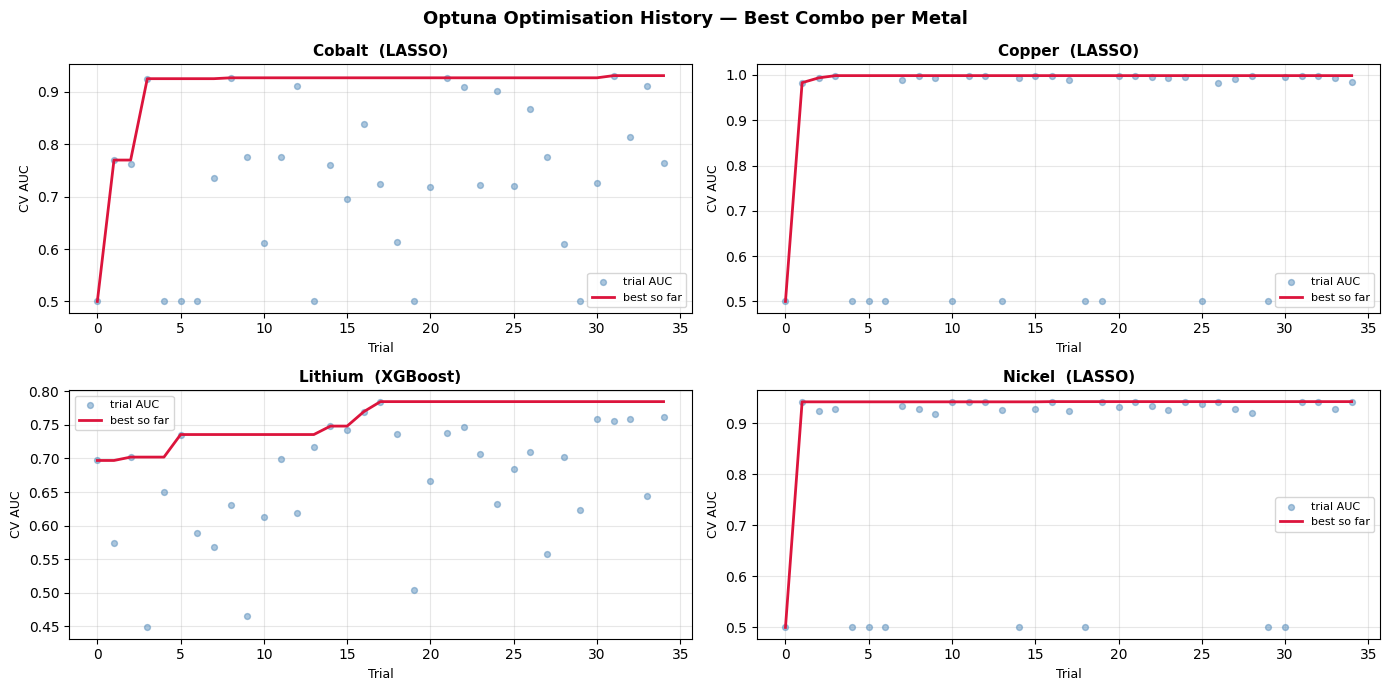


Saved → outputs/optuna_results.csv  +  04_optuna_history.png


In [8]:
# ── Identify winning combo per metal ──────────────────────────────────────
df_r_opt = df_results[df_results.Note != 'too_few_pos'].dropna(subset=['AUC']).copy()
winners  = (df_r_opt.loc[df_r_opt.groupby('Metal')['F1'].idxmax()]
            .set_index('Metal')[['Variant', 'Model']])

N_TRIALS = 35
optuna_studies    = {}
optuna_best_params = {}
optuna_rows        = []

print(f'Fine-tuning {len(winners)} winners with Optuna ({N_TRIALS} trials each):\n')
print(f'{"Metal":>10s}  {"Variant":>14s}  {"Model":>10s}  '
      f'{"AUC_base":>8s}  {"AUC_tuned":>9s}  {"Δ":>6s}')
print('-' * 68)

for metal, row in winners.iterrows():
    variant = row['Variant']
    mname   = row['Model']
    df_ml   = prepare_features(metal, variant, df)
    feats   = [c for c in df_ml.columns if c not in ['Date', 'Target']]
    X_opt   = df_ml[feats].values
    y_opt   = df_ml['Target'].values

    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(make_optuna_objective(X_opt, y_opt, mname),
                   n_trials=N_TRIALS, show_progress_bar=False)

    optuna_studies[metal]      = study
    optuna_best_params[metal]  = study.best_params

    auc_base  = float(df_r_opt.loc[
        (df_r_opt.Metal == metal) & (df_r_opt.Variant == variant) &
        (df_r_opt.Model == mname), 'AUC'].iloc[0])
    auc_tuned = study.best_value
    delta     = auc_tuned - auc_base

    optuna_rows.append({'Metal': metal, 'Variant': variant, 'Model': mname,
                        'AUC_base': round(auc_base, 3),
                        'AUC_tuned': round(auc_tuned, 3),
                        'Delta_AUC': round(delta, 3),
                        'Best_Params': str(study.best_params)})
    print(f'{metal:>10s}  {variant:>14s}  {mname:>10s}  '
          f'{auc_base:>8.3f}  {auc_tuned:>9.3f}  {delta:>+6.3f}')

pd.DataFrame(optuna_rows).to_csv('../outputs/optuna_results.csv', index=False)

# ── Optimisation history ───────────────────────────────────────────────────
fig, axes_o = plt.subplots(2, 2, figsize=(14, 7))
for ax, (metal, study) in zip(axes_o.flat, optuna_studies.items()):
    vals_t  = [t.value for t in study.trials]
    best_sf = np.maximum.accumulate(vals_t)
    ax.scatter(range(len(vals_t)), vals_t, s=18, alpha=0.45,
               color='steelblue', label='trial AUC', zorder=2)
    ax.plot(best_sf, lw=2, color='crimson', label='best so far', zorder=3)
    ax.set_title(f'{metal}  ({winners.loc[metal, "Model"]})',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('Trial', fontsize=9)
    ax.set_ylabel('CV AUC', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Optuna Optimisation History — Best Combo per Metal',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/04_optuna_history.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print(f'\nSaved → outputs/optuna_results.csv  +  04_optuna_history.png')


## 4. SHAP Feature Importance

[SHAP](https://shap.readthedocs.io) (SHapley Additive exPlanations) assigns each
feature a contribution to each prediction — grounded in cooperative game theory.

- **`TreeExplainer`** — exact, fast for RF / XGBoost / LightGBM / CatBoost  
- **`LinearExplainer`** — exact for LASSO (log-odds contributions)

SHAP values are computed on the **last ~20 % of the time series** (chronological
hold-out) fitted on the preceding data, so there is no look-ahead.

> Feature name conventions: `_Ret_L1` = lagged log-return · `_Vol10_L1` = 10-day
> rolling volatility · `_Level_L1` = lagged price · `_L1` on dummies = peer-metal
> bubble flag yesterday.


Computing SHAP values (last ~20 % of data — no look-ahead):



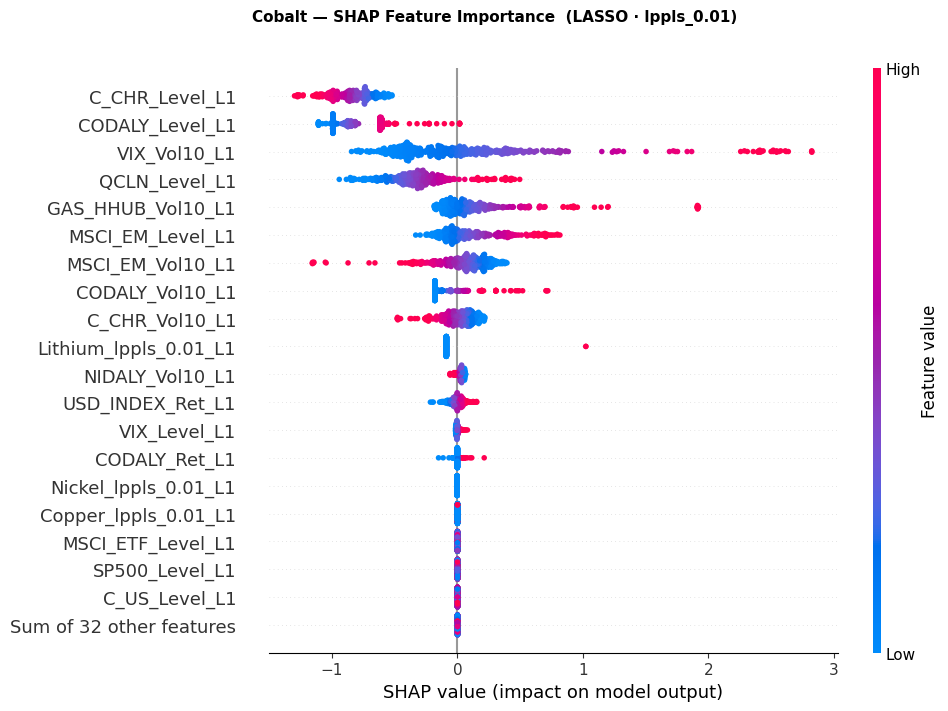

  Cobalt      top feature: C_CHR_Level_L1  (mean|SHAP|=0.8459)


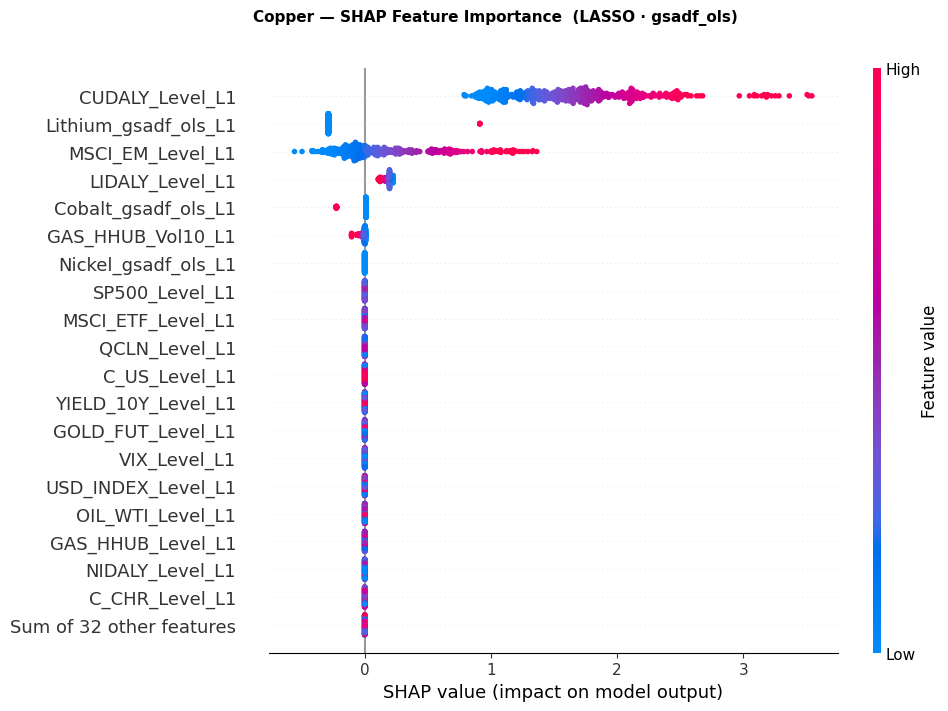

  Copper      top feature: CUDALY_Level_L1  (mean|SHAP|=1.6700)


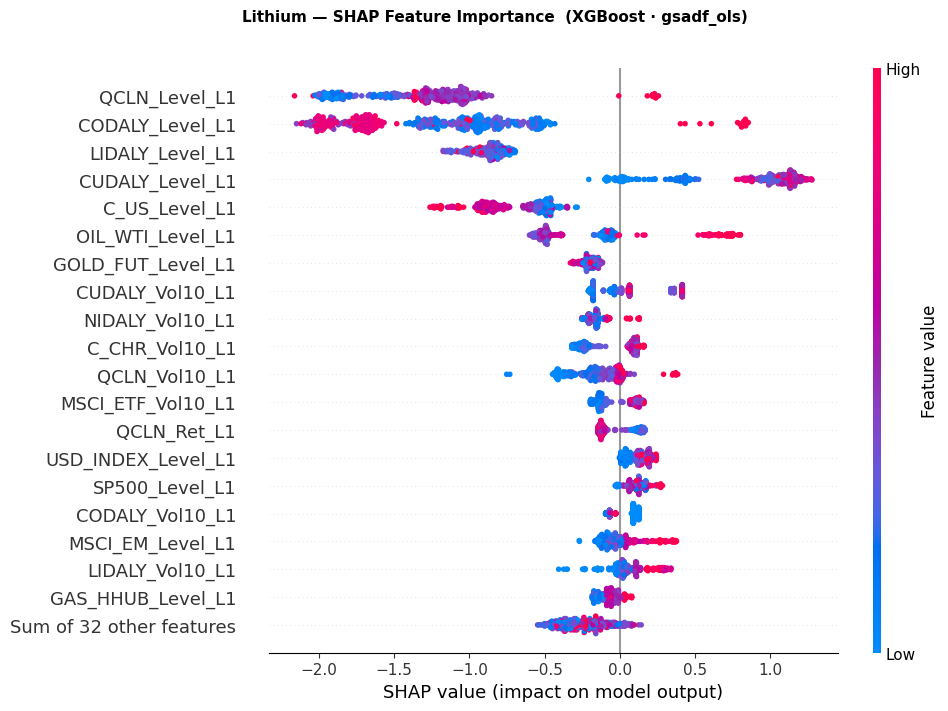

  Lithium     top feature: QCLN_Level_L1  (mean|SHAP|=1.3137)


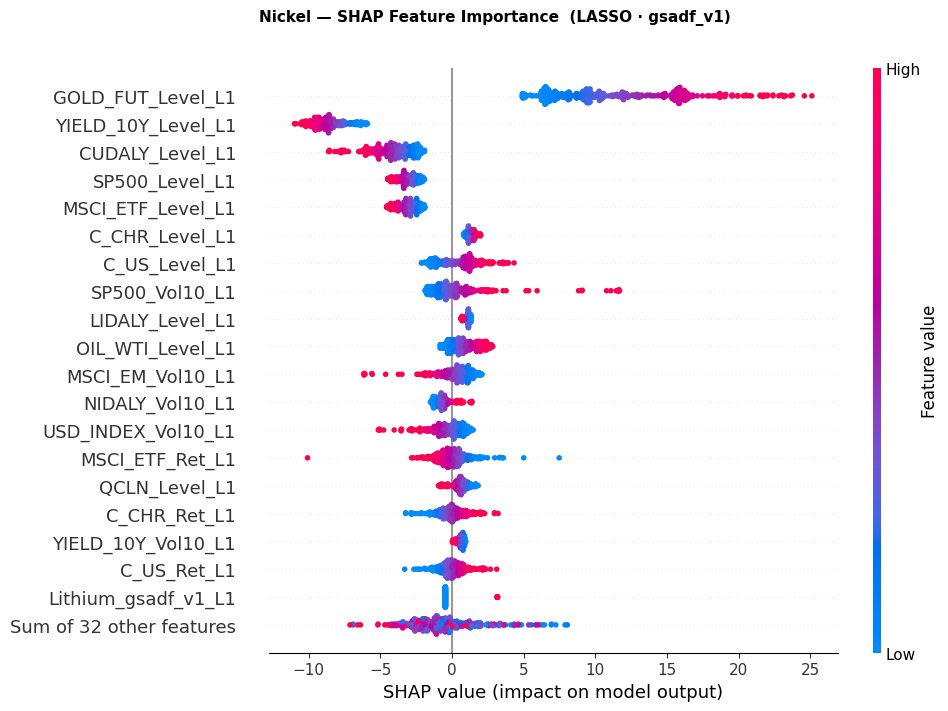

  Nickel      top feature: GOLD_FUT_Level_L1  (mean|SHAP|=11.6505)

SHAP complete. Saved outputs/shap_*.png


In [9]:
print('Computing SHAP values (last ~20 % of data — no look-ahead):\n')

for metal, row in winners.iterrows():
    variant    = row['Variant']
    mname      = row['Model']
    best_p     = optuna_best_params[metal]

    df_ml      = prepare_features(metal, variant, df)
    feats      = [c for c in df_ml.columns if c not in ['Date', 'Target']]
    X_all      = df_ml[feats].values
    y_all      = df_ml['Target'].values
    feat_names = feats

    # Chronological split: last ~20 % as explanation set
    n_test = max(100, len(X_all) // 5)
    X_tr, X_te = X_all[:-n_test], X_all[-n_test:]
    y_tr        = y_all[:-n_test]

    if mname in NEEDS_SCALE:
        sc   = StandardScaler()
        X_tr = sc.fit_transform(X_tr)
        X_te = sc.transform(X_te)

    model = build_model(mname, best_p)
    model.fit(X_tr, y_tr)

    # Compute SHAP values
    if mname in NEEDS_SCALE:
        explainer = shap.LinearExplainer(model, X_tr)
    else:
        explainer = shap.TreeExplainer(model)

    sv   = explainer(X_te)
    vals = sv.values

    # Normalise to 1-D positive-class if model returns (n, p, 2)
    if vals.ndim == 3:
        vals = vals[:, :, 1]
        base = sv.base_values[:, 1] if sv.base_values.ndim == 2 else sv.base_values
    else:
        base = sv.base_values if sv.base_values.ndim == 1 else sv.base_values[:, 0]

    sv_plot = shap.Explanation(values=vals, base_values=base,
                                data=X_te, feature_names=feat_names)

    # Beeswarm plot (shows value distribution + direction)
    shap.plots.beeswarm(sv_plot, max_display=20, show=False)
    fig = plt.gcf()
    fig.set_size_inches(10, 7)
    fig.suptitle(
        f'{metal} — SHAP Feature Importance  ({mname} · {variant})',
        fontsize=11, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'../outputs/shap_{metal.lower()}.png', dpi=150,
                bbox_inches='tight', facecolor='white')
    plt.show()

    mean_abs = np.abs(vals).mean(axis=0)
    print(f'  {metal:10s}  top feature: {feat_names[int(np.argmax(mean_abs))]}'
          f'  (mean|SHAP|={mean_abs.max():.4f})')

print('\nSHAP complete. Saved outputs/shap_*.png')
